# 03 — Model Training & Evaluation

Train early-window at-risk classifiers, compare metrics, and generate SHAP explanations.

**Inputs:** `data/processed/student_features_early.csv` (from notebook 02)

**Models:** Logistic Regression (baseline) → Random Forest → XGBoost

**Outputs:** saved model, test predictions, SHAP plots, Tableau-ready risk export

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS = PROJECT_ROOT / "models"
OUTPUTS = PROJECT_ROOT / "outputs"
MODELS.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

## 1. Load features & define X / y

In [2]:
df = pd.read_csv(PROCESSED / "student_features_early.csv")

id_cols = ["code_module", "code_presentation", "id_student"]
target_col = "at_risk"

cat_features = [
    "gender", "region", "highest_education", "imd_band", "age_band", "disability",
]
num_features = [
    "num_of_prev_attempts", "studied_credits",
    "early_clicks", "early_active_days", "early_unique_resources",
    "days_since_last_login", "vle_diversity",
    "early_mean_score", "early_n_assessments", "early_late_count",
    "early_submissions", "early_submit_mean_score",
]
feature_cols = cat_features + num_features

X = df[feature_cols]
y = df[target_col]

print(f"Rows: {len(df):,}  |  Features: {len(feature_cols)}  |  At-risk rate: {y.mean():.1%}")
X.head()

Rows: 32,593  |  Features: 18  |  At-risk rate: 52.8%


,gender,region,highest_education,imd_band,age_band,disability,num_of_prev_attempts,studied_credits,early_clicks,early_active_days,early_unique_resources,days_since_last_login,vle_diversity,early_mean_score,early_n_assessments,early_late_count,early_submissions,early_submit_mean_score
0,M,East Anglian Region,HE Qualification,90-100%,55<=,N,0,240,401.0,8.0,24.0,3.0,6.0,78.0,1.0,0.0,1.0,78.0
1,F,Scotland,HE Qualification,20-30%,35-55,N,0,60,493.0,15.0,30.0,5.0,6.0,70.0,1.0,1.0,0.0,NaN
2,F,North Western Region,A Level or Equivalent,30-40%,35-55,Y,0,60,281.0,12.0,22.0,9.0,6.0,NaN,0.0,0.0,0.0,NaN
3,F,South East Region,A Level or Equivalent,50-60%,35-55,N,0,60,453.0,17.0,30.0,1.0,7.0,72.0,1.0,0.0,1.0,72.0
4,F,West Midlands Region,Lower Than A Level,50-60%,0-35,N,0,60,518.0,21.0,33.0,0.0,7.0,69.0,1.0,1.0,0.0,NaN


## 2. Train / test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)

meta_train, meta_test = train_test_split(
    df[id_cols + ["final_result", target_col]],
    test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train at-risk rate: {y_train.mean():.1%}")

Train: 26,074  |  Test: 6,519
Train at-risk rate: 52.8%


## 3. Preprocessing pipeline

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", SimpleImputer(strategy="median"), num_features),
    ]
)

## 4. Train models

In [5]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "xgboost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
    ),
}

pipelines = {}
predictions = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    predictions[name] = pipe.predict_proba(X_test)[:, 1]
    print(f"Trained: {name}")

d:\ed_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Trained: logistic_regression
Trained: random_forest
Trained: xgboost


## 5. Evaluate & compare

In [6]:
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    from sklearn.metrics import precision_score, recall_score
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }

results = pd.DataFrame([
    evaluate_model(name, y_test, prob) for name, prob in predictions.items()
]).sort_values("roc_auc", ascending=False)

results.round(3)

,model,roc_auc,pr_auc,precision,recall
1,random_forest,0.820,0.852,0.809,0.659
2,xgboost,0.819,0.854,0.802,0.682
0,logistic_regression,0.790,0.818,0.741,0.690


Naive baseline ROC-AUC (all zeros): 0.500  ← should be ~0.50


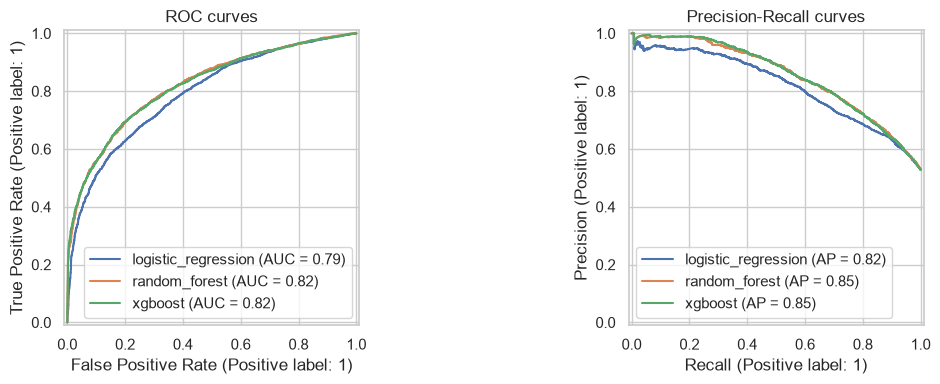

In [7]:
# Naive baseline: predict majority class (not at-risk = 0)
naive_prob = np.zeros(len(y_test))
naive_auc = roc_auc_score(y_test, naive_prob) if len(np.unique(y_test)) > 1 else np.nan
print(f"Naive baseline ROC-AUC (all zeros): {naive_auc:.3f}  ← should be ~0.50")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, prob in predictions.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=name, ax=axes[1])
axes[0].set_title("ROC curves")
axes[1].set_title("Precision-Recall curves")
plt.tight_layout()
plt.show()

Best model: random_forest
              precision    recall  f1-score   support

 not_at_risk       0.68      0.83      0.75      3077
     at_risk       0.81      0.66      0.73      3442

    accuracy                           0.74      6519
   macro avg       0.75      0.74      0.74      6519
weighted avg       0.75      0.74      0.74      6519



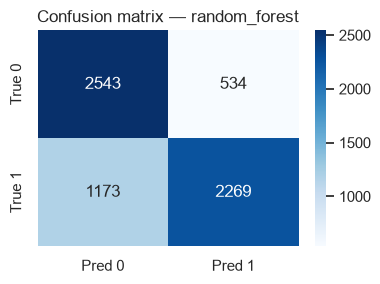

In [8]:
best_model_name = results.iloc[0]["model"]
best_pipe = pipelines[best_model_name]
best_prob = predictions[best_model_name]
best_pred = (best_prob >= 0.5).astype(int)

print(f"Best model: {best_model_name}")
print(classification_report(y_test, best_pred, target_names=["not_at_risk", "at_risk"]))

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
ax.set_title(f"Confusion matrix — {best_model_name}")
plt.tight_layout()
plt.show()

## 6. SHAP explainability (best tree model)

Use Random Forest or XGBoost — whichever wins. SHAP shows which features drive individual risk predictions.

SHAP values shape: (500, 48)  (sample n=500)


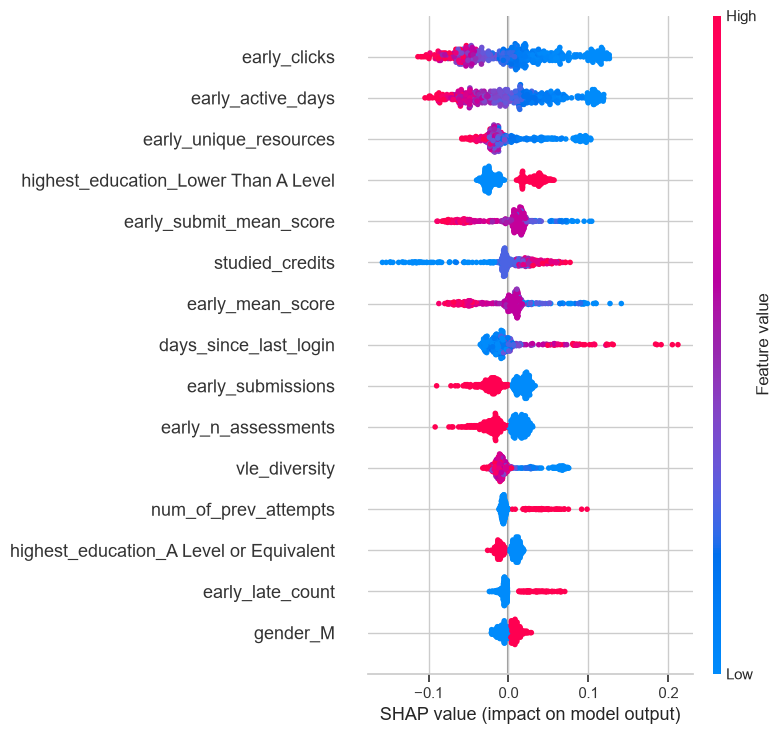

,feature,mean_abs_shap
0,early_clicks,0.048349
1,early_active_days,0.045687
2,early_unique_resources,0.028824
3,highest_education_Lower Than A Level,0.026582
4,early_submit_mean_score,0.025918
5,studied_credits,0.025910
6,early_mean_score,0.024210
7,days_since_last_login,0.021306
8,early_submissions,0.020351
9,early_n_assessments,0.018167


In [15]:
SHAP_SAMPLE_SIZE = 500  # full test set (~6.5k) is slow; 500 is enough for plots


def shap_at_risk_values(raw_shap):
    """Normalize SHAP output to (n_samples, n_features) for the at-risk class."""
    if hasattr(raw_shap, "values"):
        sv = np.asarray(raw_shap.values)
    elif isinstance(raw_shap, list):
        sv = np.asarray(raw_shap[1] if len(raw_shap) > 1 else raw_shap[0])
    else:
        sv = np.asarray(raw_shap)

    if sv.ndim == 3:
        sv = sv[:, :, 1]  # positive / at-risk class
    elif sv.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {sv.shape}")

    return sv


shap_model_name = "random_forest" if "random_forest" in pipelines else best_model_name
shap_pipe = pipelines[shap_model_name]

X_test_transformed = shap_pipe.named_steps["prep"].transform(X_test)

cat_encoder = shap_pipe.named_steps["prep"].named_transformers_["cat"]
encoded_cat_names = list(cat_encoder.get_feature_names_out(cat_features))
transformed_feature_names = encoded_cat_names + num_features

X_test_shap = pd.DataFrame(X_test_transformed, columns=transformed_feature_names)
X_shap_sample = X_test_shap.sample(min(SHAP_SAMPLE_SIZE, len(X_test_shap)), random_state=RANDOM_STATE)

tree_model = shap_pipe.named_steps["model"]
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_shap_sample)
sv = shap_at_risk_values(shap_values)

print(f"SHAP values shape: {sv.shape}  (sample n={len(X_shap_sample)})")

shap.summary_plot(sv, X_shap_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()

# Mean |SHAP| per feature — export for Tableau
mean_abs_shap = np.abs(sv).mean(axis=0)
shap_importance = (
    pd.DataFrame({"feature": transformed_feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
shap_importance.head(15)

In [16]:
# shap_importance is built in the cell above — display top features again
shap_importance.head(15)

,feature,mean_abs_shap
0,early_clicks,0.048349
1,early_active_days,0.045687
2,early_unique_resources,0.028824
3,highest_education_Lower Than A Level,0.026582
4,early_submit_mean_score,0.025918
5,studied_credits,0.025910
6,early_mean_score,0.024210
7,days_since_last_login,0.021306
8,early_submissions,0.020351
9,early_n_assessments,0.018167


## 7. Risk tiers & exports

In [17]:
def risk_tier(prob):
    if prob >= 0.6:
        return "High"
    if prob >= 0.4:
        return "Medium"
    return "Low"

test_export = meta_test.copy()
test_export["risk_probability"] = best_prob
test_export["risk_tier"] = test_export["risk_probability"].apply(risk_tier)
test_export["predicted_at_risk"] = best_pred

pred_path = OUTPUTS / "student_risk_predictions.csv"
test_export.to_csv(pred_path, index=False)

shap_path = OUTPUTS / "shap_feature_importance.csv"
shap_importance.to_csv(shap_path, index=False)

model_path = MODELS / f"{best_model_name}.joblib"
joblib.dump(best_pipe, model_path)

print(f"Predictions → {pred_path}")
print(f"SHAP importances → {shap_path}")
print(f"Model → {model_path}")
test_export["risk_tier"].value_counts()

Predictions → d:\ed_project\outputs\student_risk_predictions.csv
SHAP importances → d:\ed_project\outputs\shap_feature_importance.csv
Model → d:\ed_project\models\random_forest.joblib


risk_tier
Low       2686
High      2093
Medium    1740
Name: count, dtype: int64